In [6]:
#core
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# for evaluation and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
import pandas as pd

# The original path 'C:\Users\phadt\OneDrive\Desktop\ML Prac\currentdiabetes.csv' is a local file path and cannot be accessed by Google Colab.
# You need to upload the 'currentdiabetes.csv' file to your Colab environment or mount Google Drive.

# Option 1: Upload the file directly to Colab (e.g., using the files icon on the left sidebar).
# Once uploaded, you can typically access it directly by its filename in the working directory.
# Example: url = 'diabetes.csv'

# Option 2: Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# Then, provide the path to your file in Drive. Example:
# url = '/content/drive/MyDrive/ML Prac/currentdiabetes.csv'

# Please replace the line below with the correct path after uploading or mounting.
# For now, I'm commenting out the problematic line to allow you to fix the path.
# url = r"C:\Users\phadt\OneDrive\Desktop\ML Prac\currentdiabetes.csv"

# Placeholder for the corrected URL after you've uploaded the file.
# For demonstration, assuming you upload it directly and its name is 'currentdiabetes.csv'
# url = r"C:\Users\phadt\Downloads\diabetes.csv" # This path is incorrect for Google Colab

# === PLEASE UPDATE THE 'url' VARIABLE BELOW WITH THE CORRECT PATH ===
# If you uploaded 'diabetes.csv' directly to Colab's session storage, use: url = 'diabetes.csv'
# If you mounted Google Drive, use a path like: url = '/content/drive/MyDrive/your_folder/diabetes.csv'
url = r'C:\Users\phadt\OneDrive\Desktop\MLproj\Diabetes Ml Project (Classification)\diabetes.csv' # <-- REPLACE THIS WITH YOUR ACTUAL FILE PATH' # <-- REPLACE THIS WITH YOUR ACTUAL FILE PATH
df = pd.read_csv(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
# structure and summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
# missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
# descriptive statistics
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [11]:
#duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# data types
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [13]:
# common cleanup (optional but recommended)
# replace physiological zeros in certain columns with Nan (then impute)-datasets
zero_as_missing =['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_as_missing:
  df[col] = df[col].replace(0, np.nan)

#simple imputation : fill NaNs with median values
for col in zero_as_missing:
  df[col] = df[col].fillna(df[col].median())


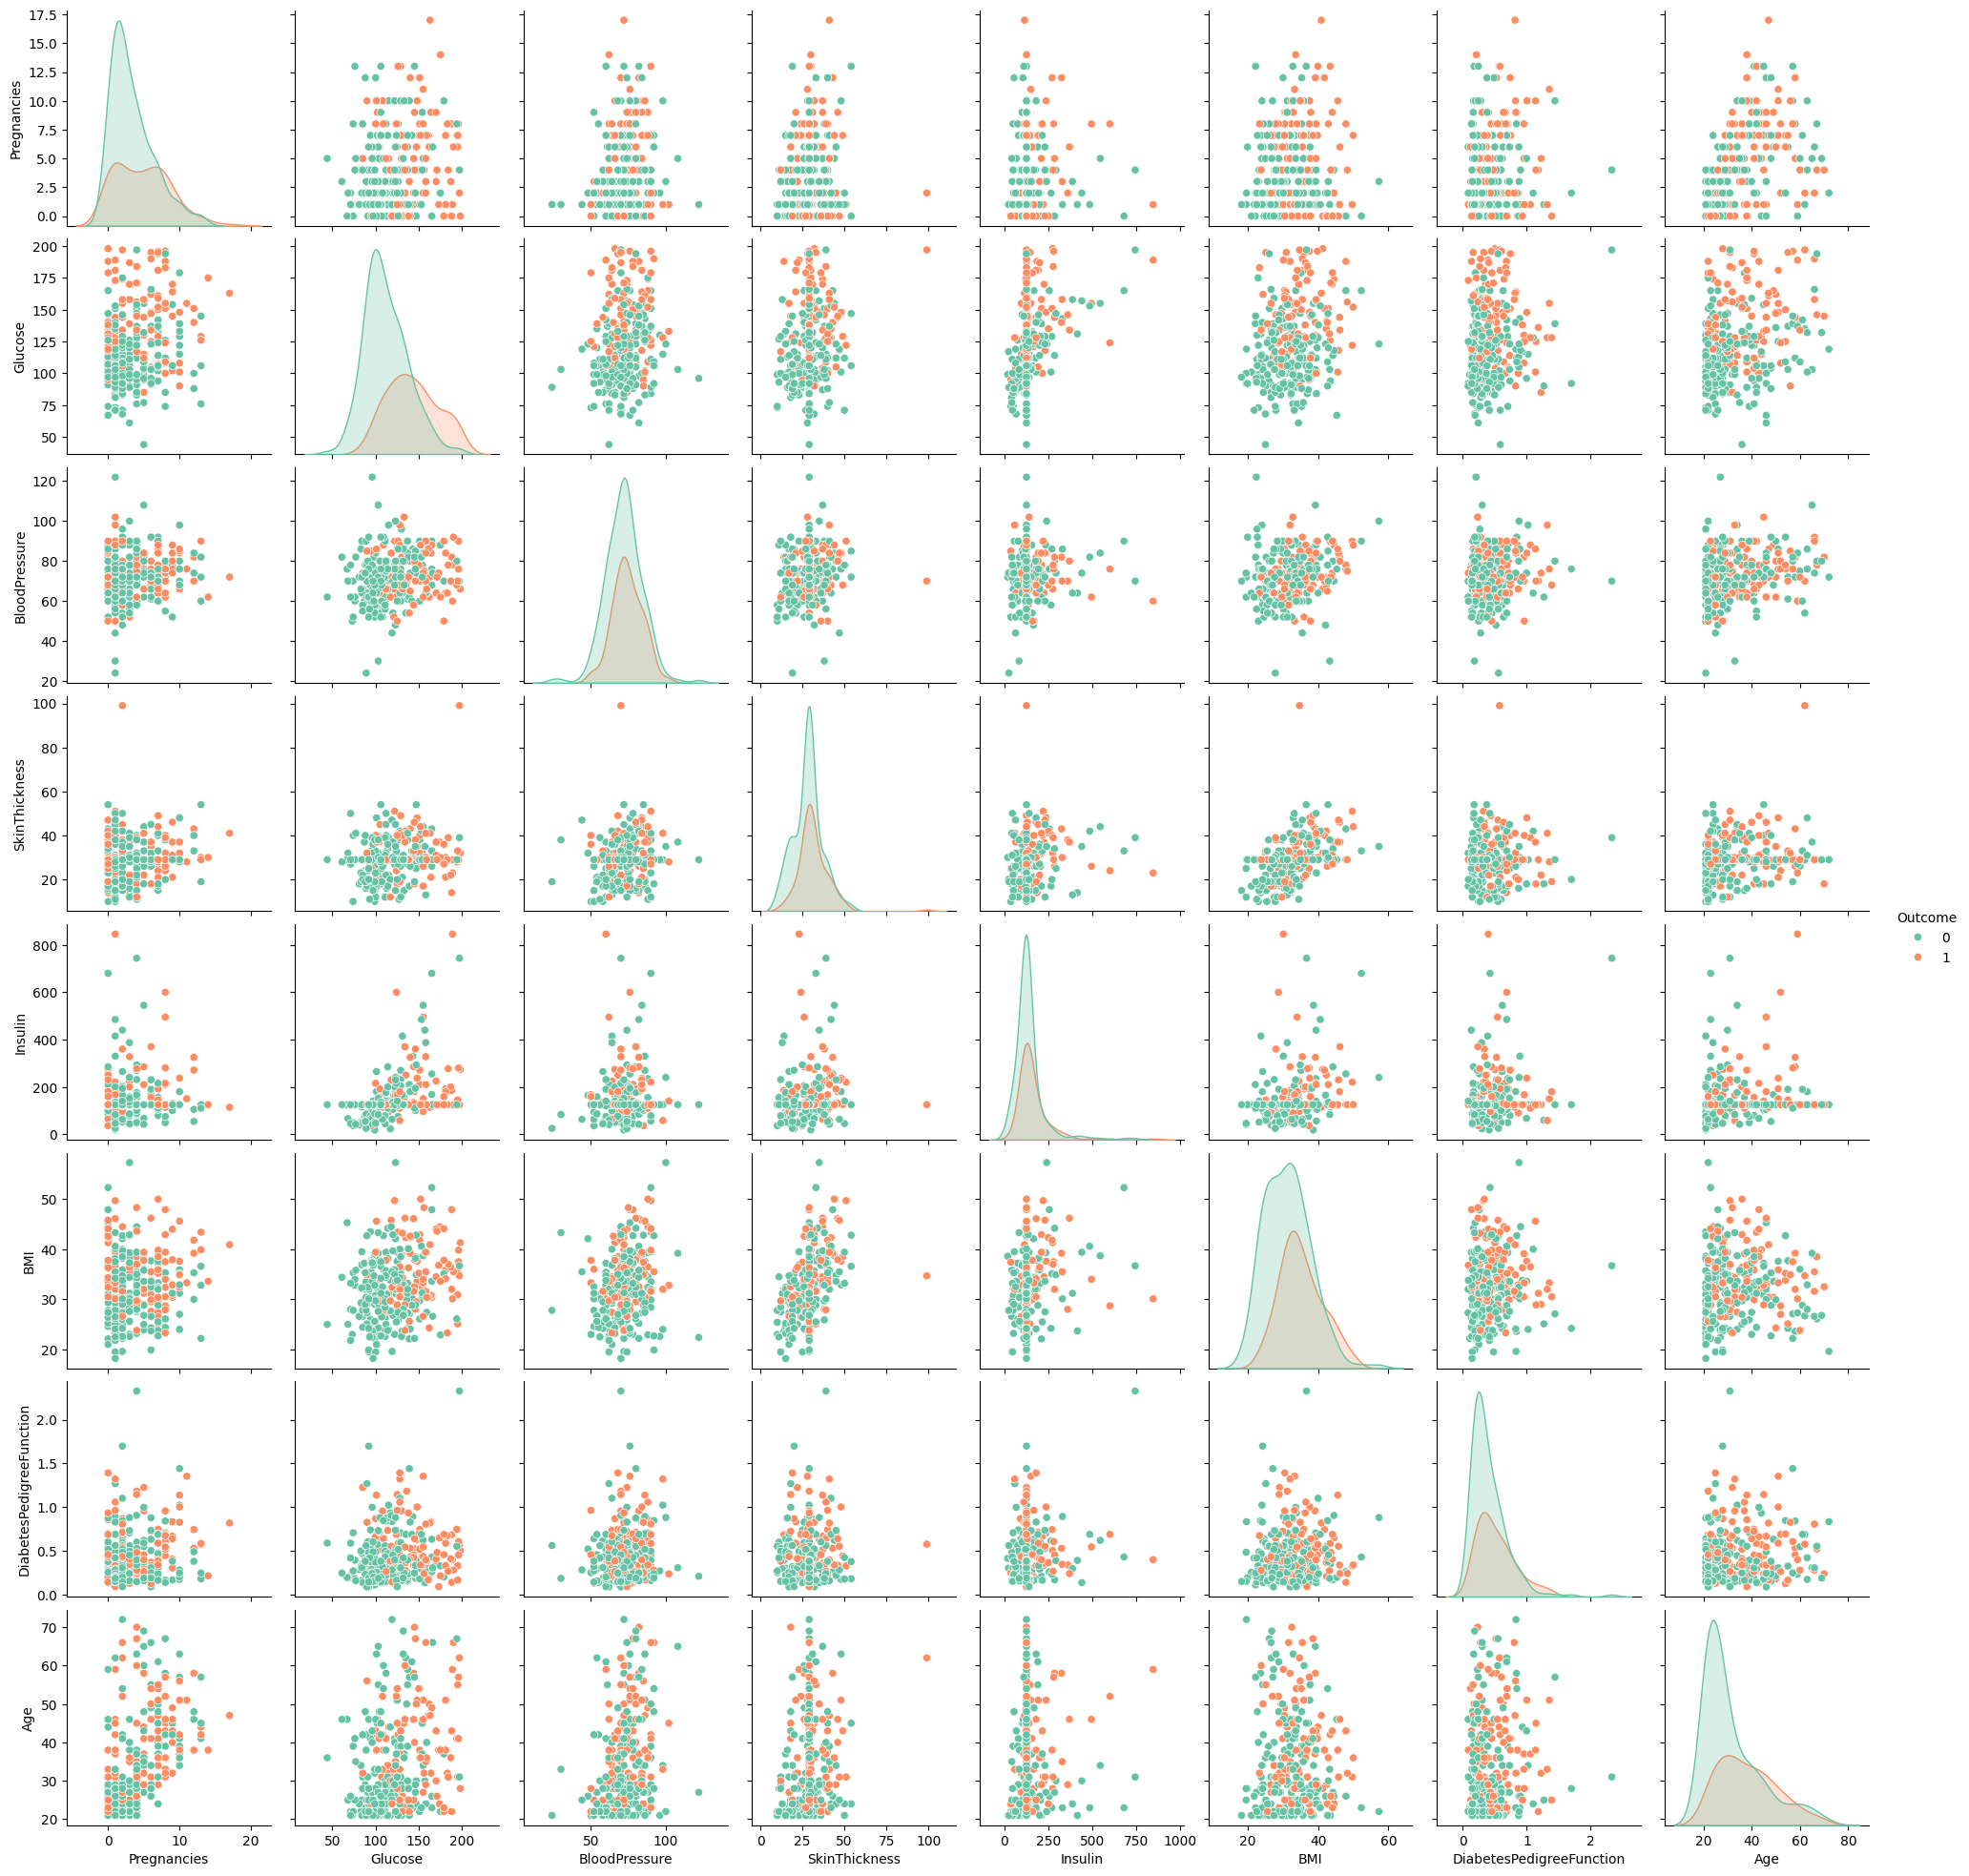

In [14]:
# Exploratory data analysis(EDA)
import matplotlib.pyplot as plt
# class balance
df['Outcome'].value_counts()
# pairwise relationships (may be dense; sample if needed)
sns.pairplot(df.sample(min(300,len(df))), hue='Outcome', palette='Set2')
plt.show()

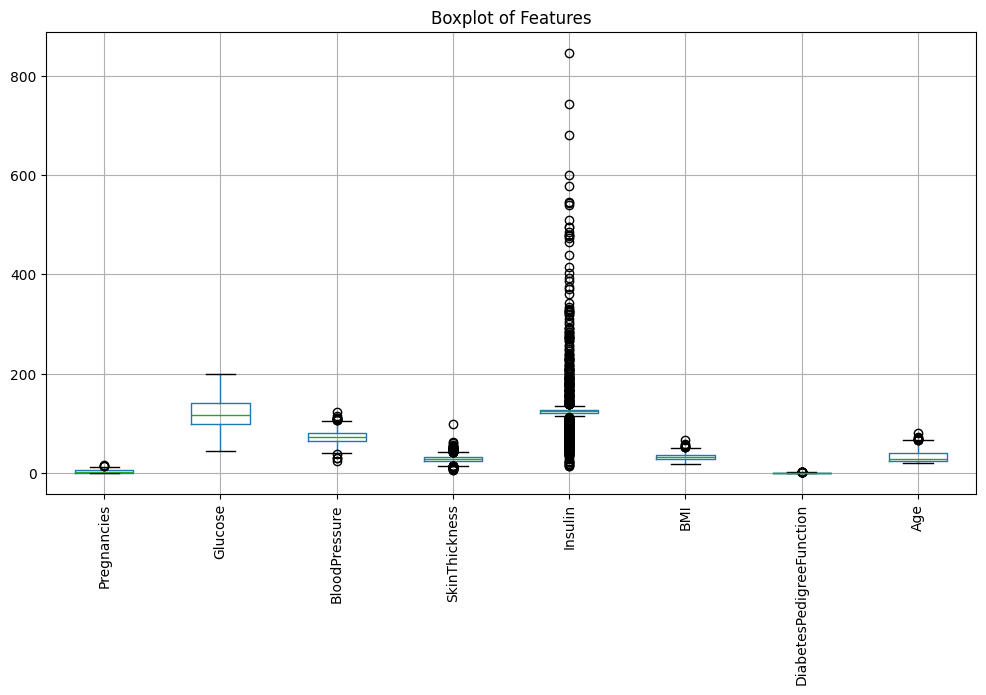

In [15]:
# Boxplot of features
plt.figure(figsize=(12,6))
df.drop(columns=['Outcome']).boxplot() # Corrected: plt.drop to df.drop
plt.title("Boxplot of Features")
plt.xticks(rotation=90)
plt.show()


<Figure size 1800x800 with 0 Axes>

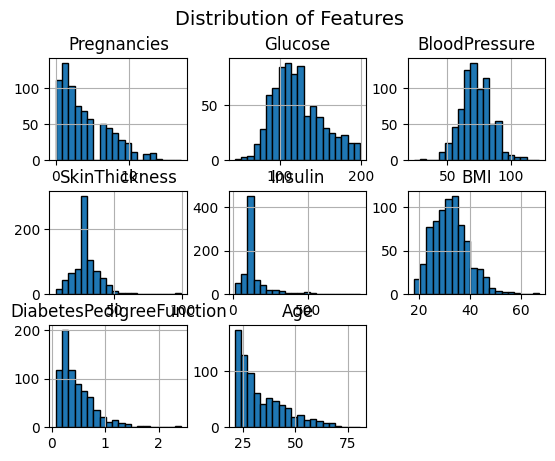

In [16]:
# Histograms
plt.figure(figsize=(18,8))
df.drop(columns=['Outcome']).hist(bins=20, edgecolor='black')
plt.suptitle("Distribution of Features", fontsize=14)
plt.show()


<Figure size 1000x800 with 0 Axes>

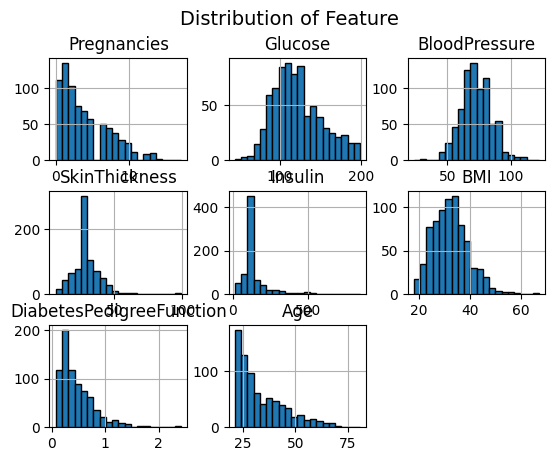

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,8))
df.drop(columns=["Outcome"]).hist(bins=20, edgecolor='black')
plt.suptitle('Distribution of Feature',fontsize=14) # Corrected: 'Featire' to 'Feature'
plt.show()

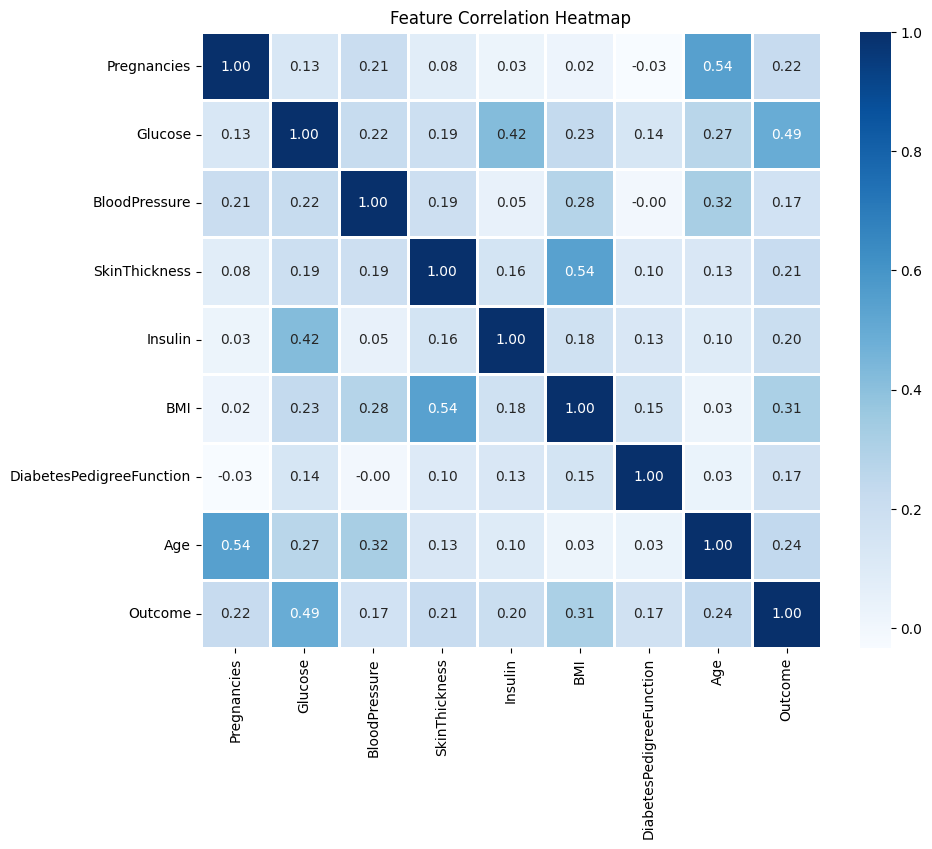

In [40]:
# correlation heatmap
plt.figure(figsize =(10,8))
sns.heatmap(df.corr(), annot = True, cmap="Blues", fmt=".2f", linewidths=1.0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [19]:
# splitting the data
# Feature and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)


In [20]:
# Feature scaling
scaler = StandardScaler()

#fir on training, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
#1) Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:,1]

accuracy_log = accuracy_score(y_test, y_pred_log)
conf_log = confusion_matrix(y_test, y_pred_log)
report_log = classification_report(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_proba_log)

print(f"Logistic Regression Accuracy: {accuracy_log:.2f}, ROC-AUC: {auc_log:.2f}")
print("Confusion Matrix:\n", conf_log)
print("Classification Report:\n", report_log)

#2) Decision Tree
tree_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
tree_clf.fit(X_train, y_train) # Trees don't require scaling
y_pred_tree = tree_clf.predict(X_test)
# For AUC with tree, use predict_proba if available
y_proba_tree = tree_clf.predict_proba(X_test)[:,1]

accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_tree = confusion_matrix(y_test, y_pred_tree)
report_tree = classification_report(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_proba_tree)

print(f"Decision Tree Accuracy: {accuracy_tree:.2f}, ROC-AUC: {auc_tree:.2f}")
print("Confusion Matrix:\n", conf_tree)
print("Classification Report:\n", report_tree)

# 3) k-Nearest Neighbors (k-NN)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
# kNN has predict_proba
y_proba_knn = knn_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_knn = confusion_matrix(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"k-NN Accuracy: {accuracy_knn:.2f}, ROC-AUC: {auc_knn:.2f}")
print("Confusion Matrix:\n", conf_knn)
print("Classification Report:\n", report_knn)

Logistic Regression Accuracy: 0.73, ROC-AUC: 0.81
Confusion Matrix:
 [[75 25]
 [16 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

Decision Tree Accuracy: 0.71, ROC-AUC: 0.65
Confusion Matrix:
 [[85 15]
 [30 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.85      0.79       100
           1       0.62      0.44      0.52        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.65       154
weighted avg       0.70      0.71      0.69       154

k-NN Accuracy: 0.75, ROC-AUC: 0.79
Confusion Matrix:
 [[83 17]
 [21 33]]
Classification Report:
               precision    reca

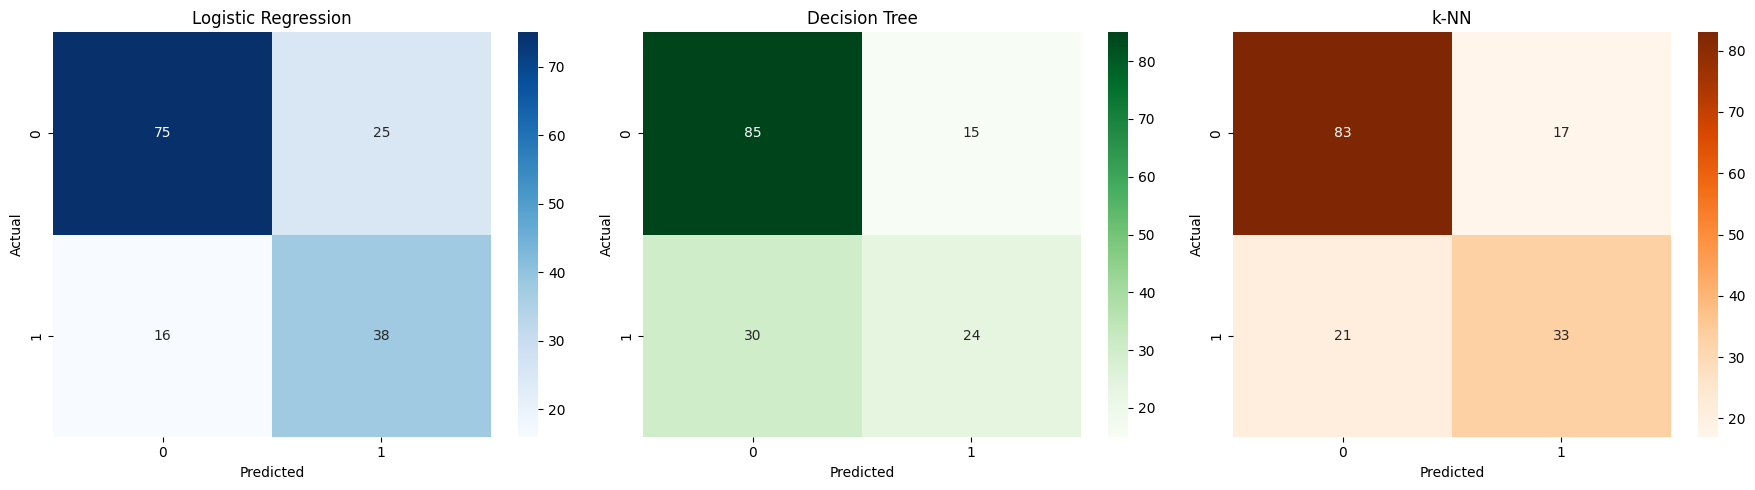

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(conf_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(conf_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

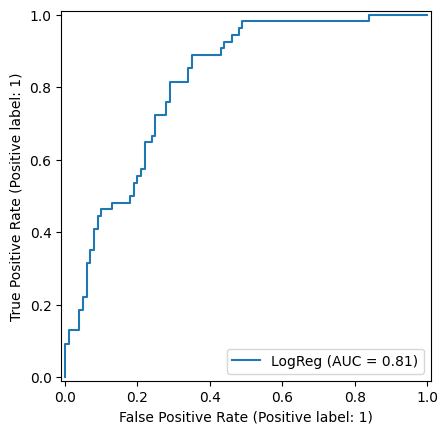

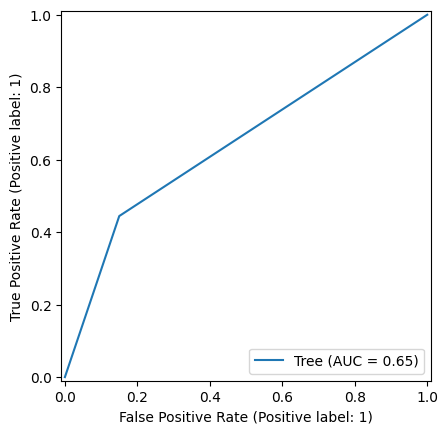

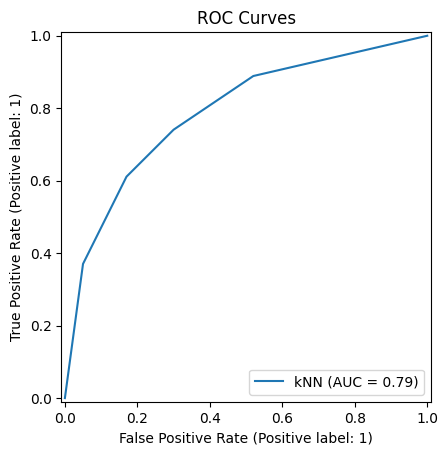

In [23]:
# ROC curves
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, y_proba_log, name="LogReg")
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name="Tree")
RocCurveDisplay.from_predictions(y_test, y_proba_knn, name="kNN")
plt.title("ROC Curves")
plt.show()

In [24]:
# Selecting and saving the best model
model_score = {
    'log_reg': auc_log,
    'tree_clf': auc_tree,
    'knn_clf': auc_knn
}

best_model_name = max(model_score, key=model_score.get)
print("Best model by ROC-AUC:", best_model_name, "=>", model_score[best_model_name])
# Retrieve object reference
best_model = {'log_reg': log_reg, 'tree_clf': tree_clf,'knn_clf': knn_clf}[best_model_name]
# Save model and scaler
import pickle
with open('diabetes_model.pkl','wb') as mf:
  pickle.dump(best_model, mf)

with open('diabetes_scaler.pkl','wb') as sf:
  pickle.dump(scaler, sf)

Best model by ROC-AUC: log_reg => 0.8125925925925926


In [43]:
import numpy as np
import pickle

# Load saved model and scaler
with open('diabetes_model.pkl', 'rb') as mf:
    model = pickle.load(mf)

with open('diabetes_scaler.pkl', 'rb') as sf:
    scaler = pickle.load(sf)

def predict_diabetes(input_data):
    """
    input_data: list or tuple of 8 numerical features
    Returns: text output instead of numeric prediction
    """
    arr = np.array(input_data).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    prediction = model.predict(arr_scaled)[0]

    if prediction == 1:
        return "Person is diabetic"
    else:
        return "Person is not diabetic"


In [44]:
sample_1 = [6, 148, 72, 35, 0, 33.6, 0.627, 50]
print(predict_diabetes(sample_1))
# Output: Person is diabetic

Person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
